# Spending evaluation effort where it changes the answer

Most positions in a search are not close calls. A rook up in a quiet endgame
needs a material count, not a neural network and certainly not a language
model. A tiered evaluator estimates how much a position is worth thinking about
and routes it accordingly, under a latency budget it may not overspend.

The strongest signal is the gap between the static evaluation and what a
quiescence search says. If those two agree the position is quiet almost by
definition.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

## What complexity looks like

In [2]:
import chess
from engine.evaluation.complexity import estimate_complexity
from engine.evaluation.tapered import positional_eval

cases = {
    "bare kings": "8/8/4k3/8/8/4K3/8/8 w - - 0 1",
    "quiet endgame": "8/8/4k3/8/8/4K3/8/4R3 w - - 0 1",
    "start position": chess.STARTING_FEN,
    "closed middlegame": "r1bq1rk1/pp2ppbp/2np1np1/8/2BNP3/2N1BP2/PPPQ2PP/R3K2R w KQ - 0 9",
    "hanging queen": "4k3/8/8/3q4/4P3/8/8/3QK3 w - - 0 1",
    "checkmate": "rnb1kbnr/pppp1ppp/8/4p3/6Pq/5P2/PPPPP2P/RNBQKBNR w KQkq - 1 3",
}
signals = {name: estimate_complexity(chess.Board(fen), positional_eval) for name, fen in cases.items()}
for name, signal in signals.items():
    print(f"{name:<20} {signal.score:.2f}  {signal.explain()}")

bare kings           0.03  complexity 0.03 — 8 moves, 0 captures, 0cp hanging, tactical gap 0cp
quiet endgame        0.07  complexity 0.07 — 16 moves, 0 captures, 0cp hanging, tactical gap 0cp
start position       0.17  complexity 0.17 — 20 moves, 0 captures, 0cp hanging, tactical gap 0cp
closed middlegame    0.44  complexity 0.44 — 52 moves, 2 captures, 320cp hanging, tactical gap 19cp
hanging queen        0.69  complexity 0.69 — 19 moves, 2 captures, 900cp hanging, tactical gap 915cp
checkmate            0.00  complexity 0.00 — 0 moves, 0 captures, 0cp hanging, tactical gap 0cp, in check


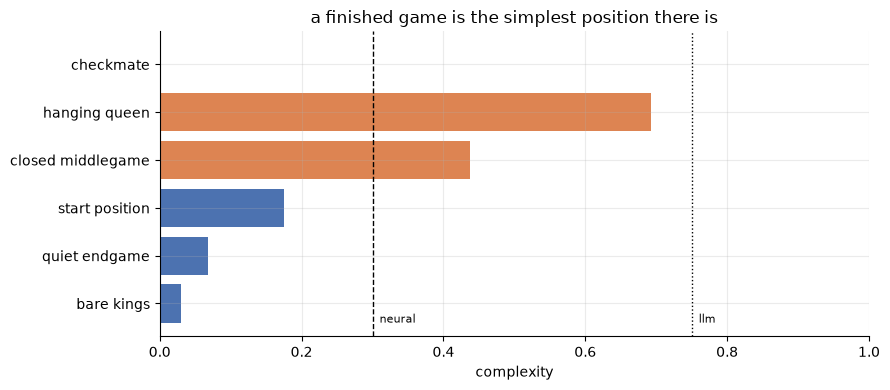

In [3]:
names = list(signals)
scores = [signals[n].score for n in names]
colours = ["#4c72b0" if s < 0.3 else "#dd8452" if s < 0.75 else "#c44e52" for s in scores]

fig, axis = plt.subplots(figsize=(9, 4))
axis.barh(names, scores, color=colours)
axis.axvline(0.30, color="black", ls="--", lw=1)
axis.axvline(0.75, color="black", ls=":", lw=1)
axis.text(0.31, -0.4, "neural", fontsize=8); axis.text(0.76, -0.4, "llm", fontsize=8)
axis.set_xlim(0, 1); axis.set_xlabel("complexity")
axis.set_title("a finished game is the simplest position there is")
plt.tight_layout(); plt.show()

**The checkmate row is a bug that a test now guards.** The quiescence probe
reported a mate-sized "tactical gap" for a position with no legal moves, which
routed a finished game to the most expensive tier available. A position with
nothing to decide is the least complex one there is.

## Routing, and the clock

The language-model tier is the only one that can lose a game on time, so it is
the only one that has to ask permission.

In [4]:
from research.hybrid_eval.tiered_evaluator import LatencyBudget, Tier, TierPolicy, TieredEvaluator
from research.self_play.value_learner import PieceSquareEvaluator
import time

class SlowModel:
    """Stands in for a language model: seconds per call, and it counts them."""
    def __init__(self, latency=0.4):
        self.latency, self.calls = latency, 0
    def evaluate(self, board):
        self.calls += 1
        time.sleep(self.latency)
        return positional_eval(board)

neural = PieceSquareEvaluator.from_engine_tables().static_eval
model = SlowModel()
evaluator = TieredEvaluator(positional_eval, neural, model,
                            policy=TierPolicy(llm_threshold=0.6),
                            budget=LatencyBudget(total_ms=1500, reserve_ms=200, max_llm_calls=2))
evaluator.new_move()
for name, fen in cases.items():
    if chess.Board(fen).is_game_over():
        continue
    result = evaluator.evaluate(chess.Board(fen))
    note = " (cached)" if result.cached else (f" (downgraded from {result.downgraded_from.value})"
                                              if result.downgraded_from else "")
    print(f"{name:<20} -> {result.tier.value:<10} {result.latency_ms:8.1f} ms{note}")
print()
print(evaluator.stats.table())
print("model calls:", model.calls)

quiet endgame        -> classical       0.0 ms
start position       -> classical       0.1 ms
closed middlegame    -> neural          2.0 ms
hanging queen        -> neural          0.1 ms (downgraded from llm)

tier         calls    mean ms   total ms
----------------------------------------
classical        2      0.056        0.1
neural           2      1.030        2.1
llm              0      0.000        0.0
cache hits: 0, downgrades: 1
model calls: 0


## What the routing saves

The question is not whether the expensive tier is better — it is whether
spending on it beats spending the same time on more search.

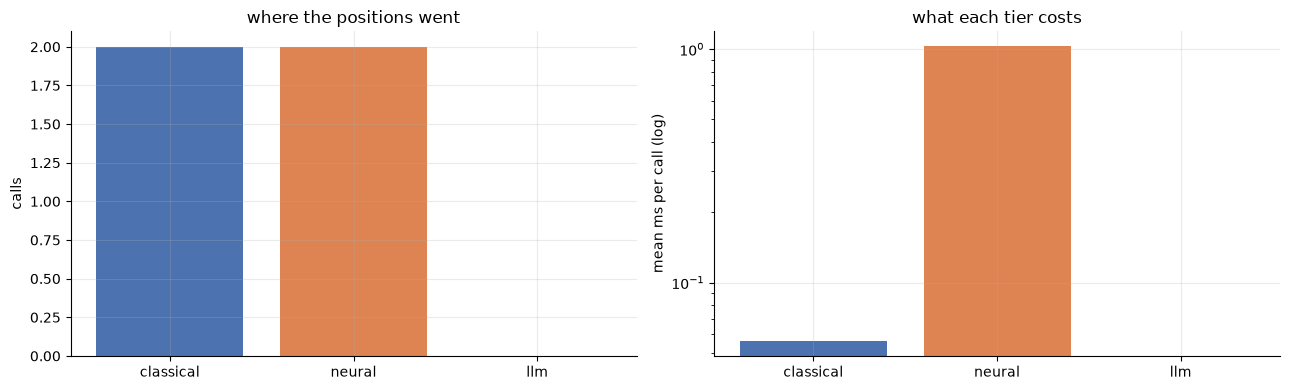

In [5]:
tiers = [t.value for t in Tier]
calls = [evaluator.stats.calls[t] for t in Tier]
mean_ms = [evaluator.stats.mean_latency_ms(t) for t in Tier]

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.bar(tiers, calls, color=["#4c72b0", "#dd8452", "#c44e52"])
left.set_ylabel("calls"); left.set_title("where the positions went")
right.bar(tiers, mean_ms, color=["#4c72b0", "#dd8452", "#c44e52"])
right.set_yscale("log"); right.set_ylabel("mean ms per call (log)")
right.set_title("what each tier costs")
plt.tight_layout(); plt.show()

## Where this can and cannot go

Routing per *leaf* does not survive contact with the numbers. A leaf evaluation
costs about six microseconds; a complexity estimate that includes a quiescence
probe costs tens; a language model costs seconds. Deciding per leaf would cost
more than the decision saves, and calling a model per leaf is off by six orders
of magnitude.

So the routing happens once, at the **root**, where a millisecond of thought can
redirect seconds of search. That is what Level 8 does: it uses the same
complexity estimate to stretch or shrink its clock.

In [6]:
from engine.levels import Level8Neural

engine = Level8Neural(seed=1, time_limit=1.0)
print(f"{'position':<20} {'complexity':>10} {'clock':>8}   depth reached")
for name, fen in cases.items():
    board = chess.Board(fen)
    if board.is_game_over():
        continue
    allowed = engine.time_for(board)
    result = engine.analyse(board)
    print(f"{name:<20} {engine.last_complexity.score:>10.2f} {allowed:>7.2f}s   {result.depth}")

position             complexity    clock   depth reached


quiet endgame              0.07    0.60s   8


start position             0.17    0.76s   6


closed middlegame          0.44    1.16s   5


hanging queen              0.69    1.54s   8
